# Decoded Plots

In [14]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from pathlib import Path


csv_path = Path("../../output/decoded.csv")
csv_path = Path("../../output/encode_decode_no_wa.csv")
df = pd.read_csv(csv_path)

In this set, `volume_noise` is fixed at `0.01`.
Each message is evaluated across combinations of `frequency` and `volume_gain_data`.
The plots below fix one message at a time to show how frequency and data volume affect error rate.

## Message-wise Frequency and Data Volume Plots

In [15]:
from pandas import DataFrame
import numpy as np


def format_float_label(value: float, decimals: int = 2) -> str:
    return f"{value:.{decimals}f}".rstrip("0").rstrip(".")


def shorten_message(text: object, max_len: int = 70) -> str:
    clean = " ".join(str(text).split())
    if len(clean) <= max_len:
        return clean
    return clean[: max_len - 3] + "..."


def prepare_plot_df(df: DataFrame) -> DataFrame:
    plot_df = df.copy()

    if "status" in plot_df.columns:
        plot_df = plot_df[plot_df["status"].astype(str).str.lower() == "success"]

    for col in ["frequency", "volume_gain_data", "error_rate"]:
        plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

    plot_df = plot_df.dropna(subset=["message", "frequency", "volume_gain_data", "error_rate"])
    plot_df["message_label"] = plot_df["message"].astype(str)
    return plot_df


def plot_error_rate_heatmaps_by_message(df: DataFrame) -> None:
    plot_df = prepare_plot_df(df)
    messages = plot_df["message_label"].drop_duplicates().tolist()

    for message in messages:
        subset = plot_df[plot_df["message_label"] == message]
        pivot = (
            subset.pivot_table(
                index="volume_gain_data",
                columns="frequency",
                values="error_rate",
                aggfunc="mean",
            )
            .sort_index()
            .sort_index(axis=1)
        )

        if pivot.empty:
            continue

        _, ax = plt.subplots(figsize=(14, 5))
        image = ax.imshow(
            pivot.values,
            cmap="viridis",
            aspect="auto",
            origin="lower",
            vmin=0,
            vmax=1,
        )

        ax.set_xticks(np.arange(len(pivot.columns)))
        ax.set_xticklabels([str(int(v)) for v in pivot.columns], rotation=45, ha="right")

        ax.set_yticks(np.arange(len(pivot.index)))
        ax.set_yticklabels([format_float_label(v, decimals=3) for v in pivot.index])

        ax.set_xlabel("Frequency")
        ax.set_ylabel("Volume Gain Data")
        ax.set_title(f"Error Rate Heatmap | Message: {shorten_message(message)}")

        color_bar = plt.colorbar(image, ax=ax)
        color_bar.set_label("Error Rate")

        plt.tight_layout()
        plt.show()


def plot_error_rate_vs_frequency_by_message(df: DataFrame) -> None:
    plot_df = prepare_plot_df(df)
    messages = plot_df["message_label"].drop_duplicates().tolist()

    for message in messages:
        subset = plot_df[plot_df["message_label"] == message]
        if subset.empty:
            continue

        _, ax = plt.subplots(figsize=(14, 5))
        for frequency, grouped in subset.groupby("frequency"):
            grouped = grouped.sort_values("volume_gain_data")
            ax.plot(
                grouped["volume_gain_data"],
                grouped["error_rate"],
                marker="o",
                linewidth=2,
                markersize=5,
                label=f"Freq: {int(frequency)}",
            )

        ax.set_xlabel("Volume Gain Data")
        ax.set_ylabel("Error Rate")
        ax.set_ylim(0, 1)
        ax.set_title(f"Error Rate vs Volume Gain Data | Message: {shorten_message(message)}")
        ax.legend(title="Frequency", ncol=3)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


def plot_error_rate_variance_by_frequency(
    df: DataFrame,
    fixed_volume_gain_data: float,
    prefer_box_if_sparse: bool = True,
    min_points_per_group: int = 3,
    atol: float = 1e-9,
) -> None:
    plot_df = prepare_plot_df(df)
    available_values = np.sort(plot_df["volume_gain_data"].unique())

    if available_values.size == 0:
        raise ValueError("No valid 'volume_gain_data' values found after preprocessing.")

    subset = plot_df[np.isclose(plot_df["volume_gain_data"], fixed_volume_gain_data, atol=atol)]
    used_volume_gain_data = fixed_volume_gain_data

    if subset.empty:
        nearest = float(available_values[np.argmin(np.abs(available_values - fixed_volume_gain_data))])
        subset = plot_df[np.isclose(plot_df["volume_gain_data"], nearest, atol=atol)]
        used_volume_gain_data = nearest

    if subset.empty:
        raise ValueError("No rows available for the selected 'volume_gain_data'.")

    frequencies = sorted(subset["frequency"].dropna().astype(float).unique().tolist())
    data = [np.asarray(subset.loc[subset["frequency"] == freq, "error_rate"], dtype=float) for freq in frequencies]
    counts = np.array([len(values) for values in data])

    use_box_plot = prefer_box_if_sparse and (counts < min_points_per_group).any()

    _, ax = plt.subplots(figsize=(14, 6))
    x_positions = np.arange(1, len(frequencies) + 1)

    if use_box_plot:
        ax.boxplot(
            data,
            positions=x_positions,
            patch_artist=True,
            boxprops={"facecolor": "#8ecae6", "alpha": 0.65},
            medianprops={"color": "#023047", "linewidth": 2},
        )
        ax.set_xticks(x_positions)
        ax.set_xticklabels([str(int(freq)) for freq in frequencies])
        chart_type = "Box"
    else:
        parts = ax.violinplot(
            data,
            positions=x_positions,
            widths=0.85,
            showmeans=False,
            showmedians=True,
            showextrema=True,
        )
        bodies = parts.get("bodies", [])
        if isinstance(bodies, list):
            for body in bodies:
                body.set_facecolor("#ffb703")
                body.set_edgecolor("#023047")
                body.set_alpha(0.7)

        ax.set_xticks(x_positions)
        ax.set_xticklabels([str(int(freq)) for freq in frequencies])
        chart_type = "Violin"

    rng = np.random.default_rng(seed=7)
    for idx, values in enumerate(data, start=1):
        values_arr = np.asarray(values, dtype=float)
        jitter = rng.uniform(-0.07, 0.07, size=len(values_arr))
        ax.scatter(
            np.full(len(values_arr), idx) + jitter,
            values_arr,
            s=16,
            alpha=0.55,
            color="#1d3557",
            linewidths=0,
        )

    ax.set_xlabel("Frequency")
    ax.set_ylabel("Error Rate")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.25)
    ax.set_title(
        f"{chart_type} Plot | Error Rate Variance by Frequency | "
        f"volume_gain_data={format_float_label(used_volume_gain_data, 6)}"
    )

    if not np.isclose(used_volume_gain_data, fixed_volume_gain_data, atol=atol):
        print(
            "Requested volume_gain_data not found exactly; "
            f"using nearest value {used_volume_gain_data:.6f}."
        )

    plt.tight_layout()
    plt.show()


def plot_error_rate_variance_for_all_volume_gains(
    df: DataFrame,
    prefer_box_if_sparse: bool = True,
    min_points_per_group: int = 3,
) -> None:
    plot_df = prepare_plot_df(df)
    volume_values = sorted(plot_df["volume_gain_data"].dropna().astype(float).unique().tolist())

    if not volume_values:
        raise ValueError("No valid 'volume_gain_data' values found after preprocessing.")

    print(f"Generating {len(volume_values)} plots (one per volume_gain_data).")
    for volume_value in volume_values:
        plot_error_rate_variance_by_frequency(
            df,
            fixed_volume_gain_data=float(volume_value),
            prefer_box_if_sparse=prefer_box_if_sparse,
            min_points_per_group=min_points_per_group,
        )

## Error Rate Heatmaps by Message

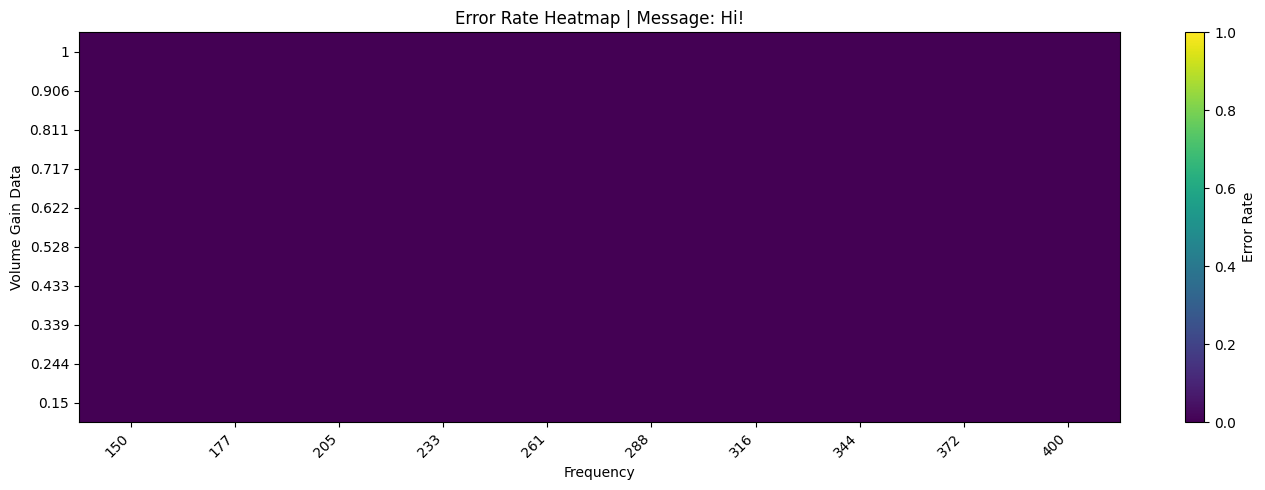

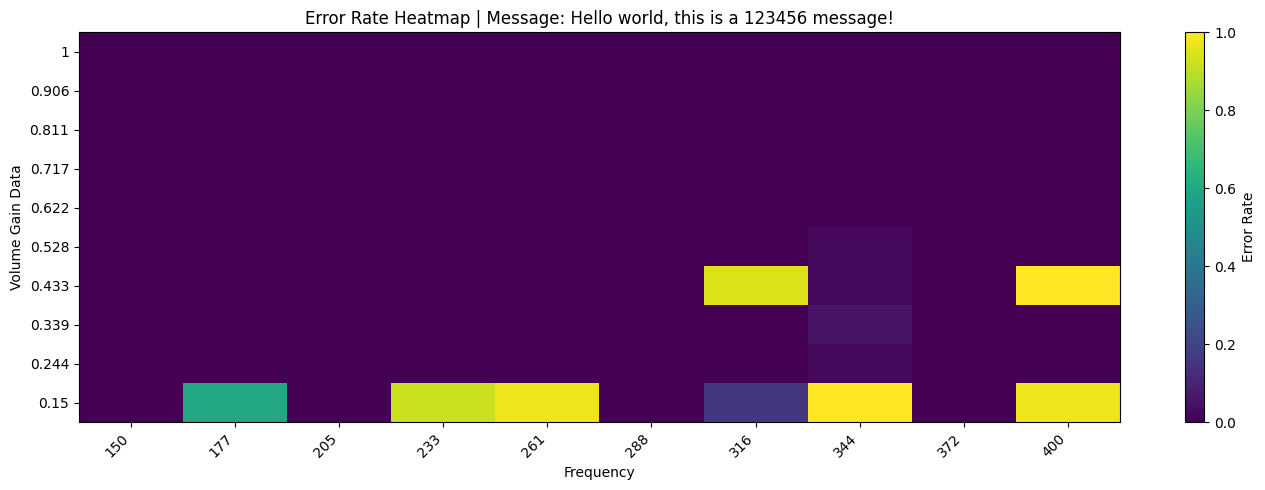

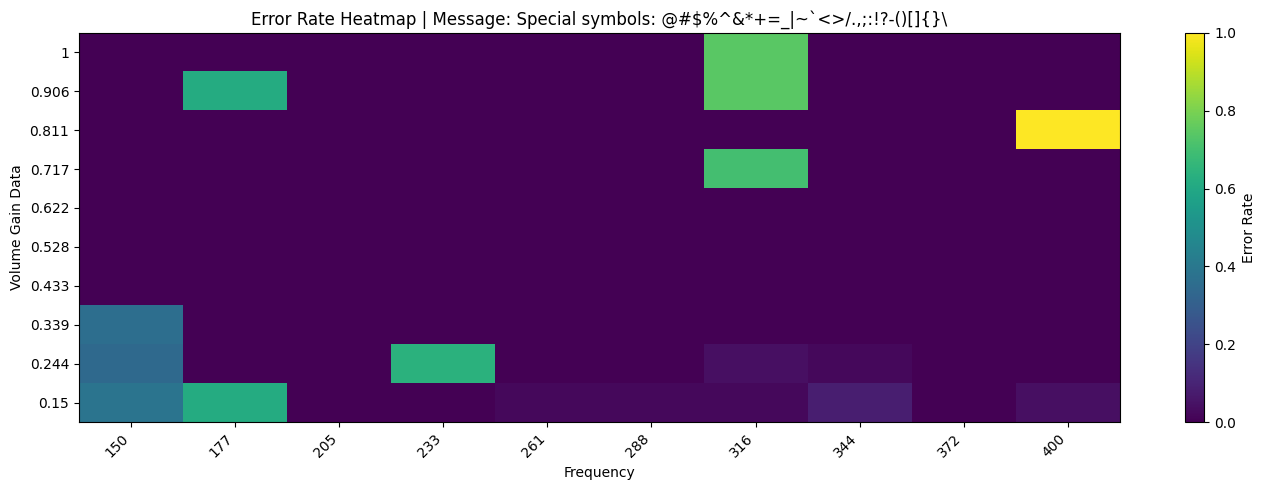

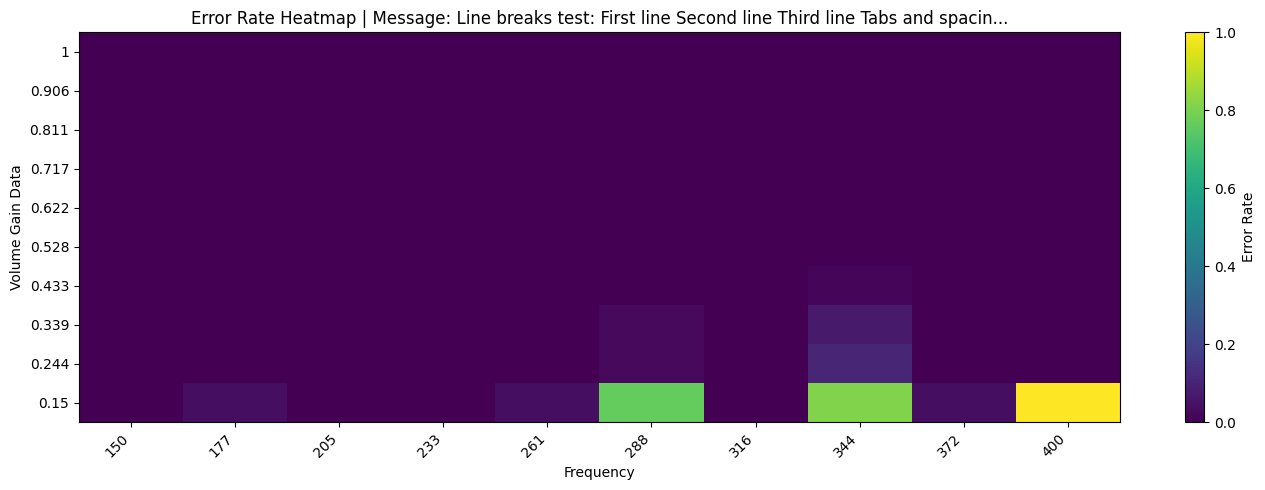

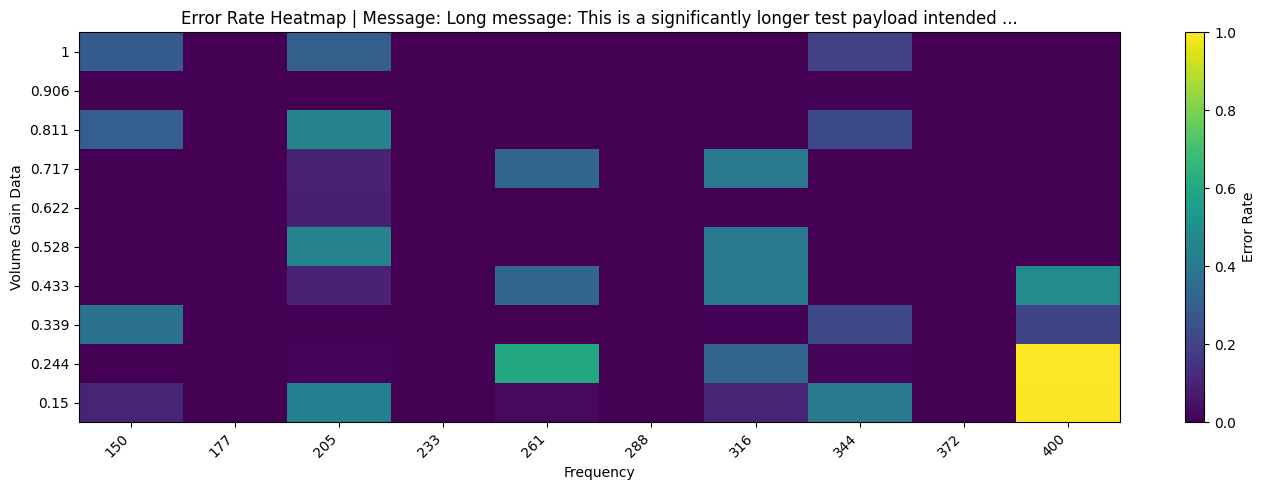

In [16]:
plot_error_rate_heatmaps_by_message(df)

## Error Rate vs Frequency (one chart per message)

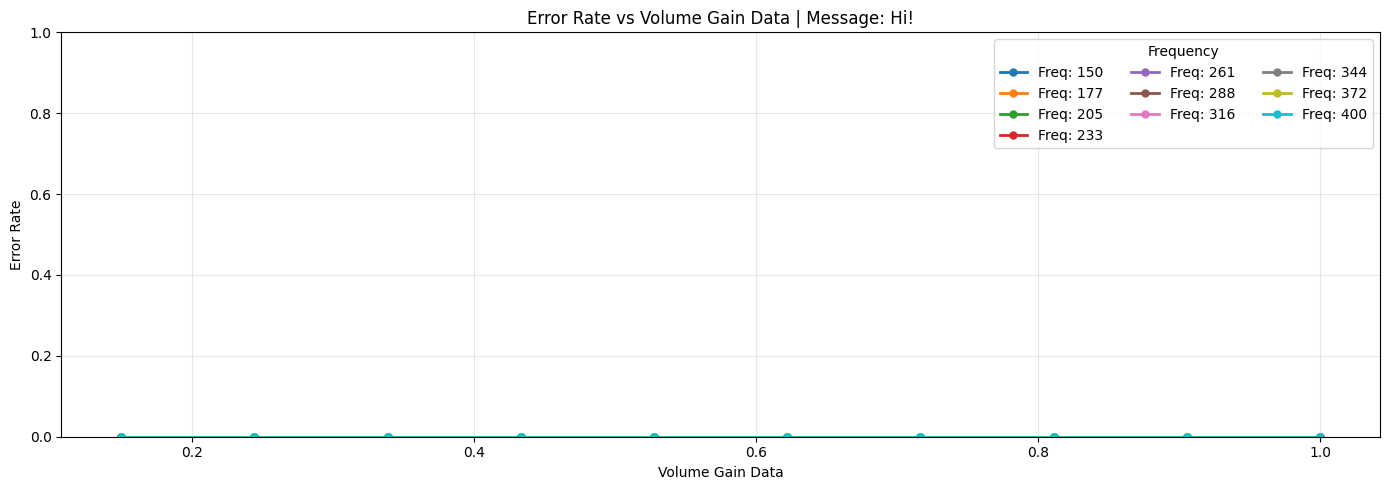

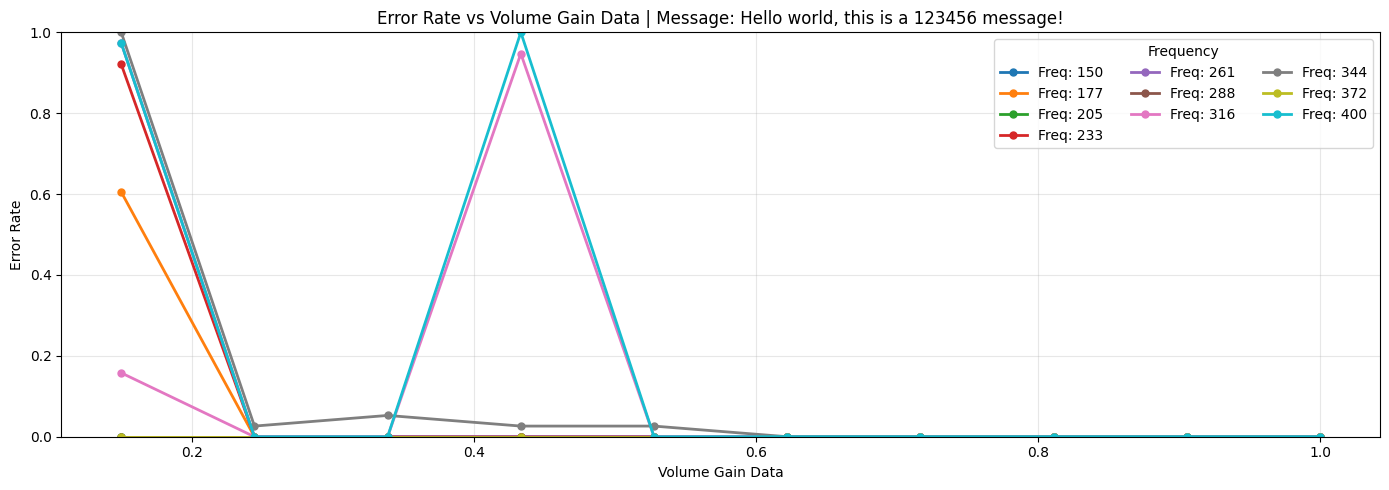

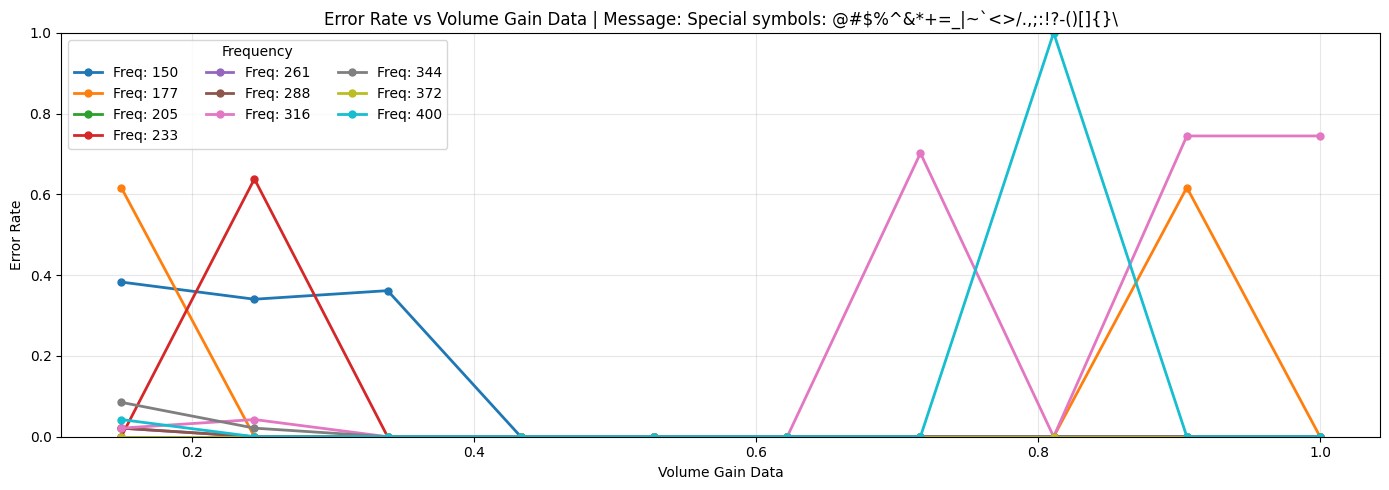

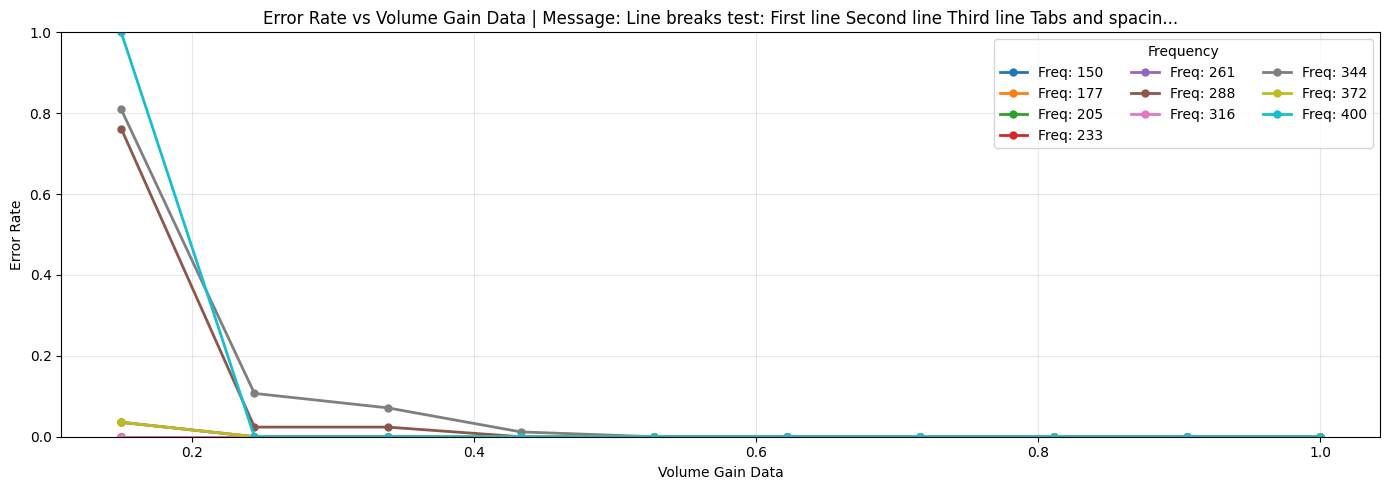

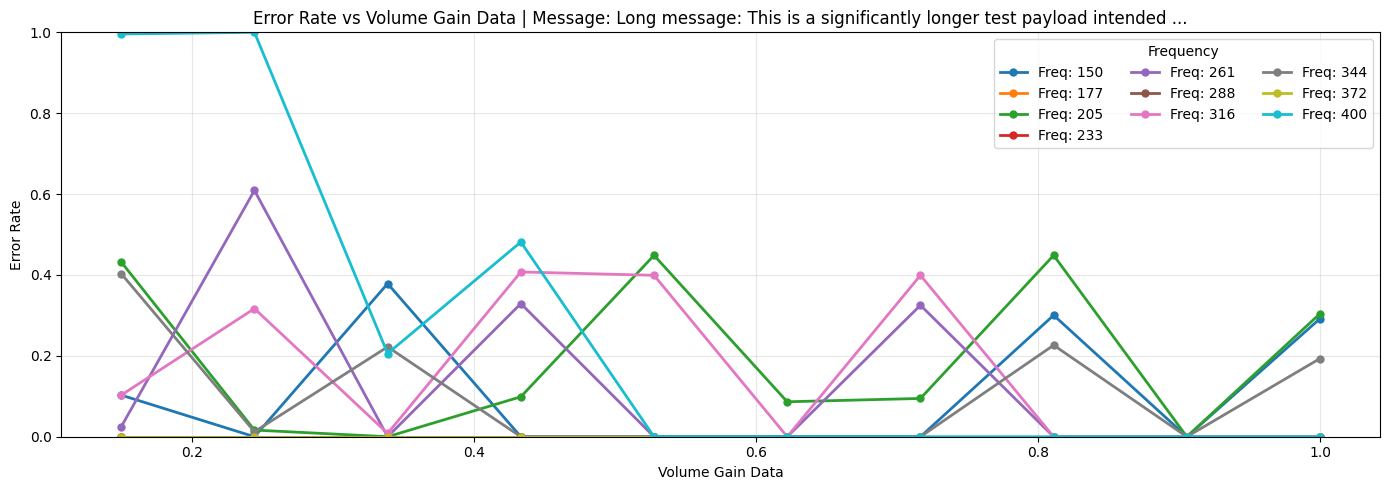

In [17]:
plot_error_rate_vs_frequency_by_message(df)

## Error Rate Variance by Frequency (All Volume Gain Data Values)
This section generates one distribution plot per available `volume_gain_data` value.
Each plot compares `error_rate` variance across frequencies.
It uses **violin plots** by default and automatically falls back to **box plots** when groups are too sparse.
This is useful to compare the variance in error rate among all test messages.

Generating 10 plots (one per volume_gain_data).


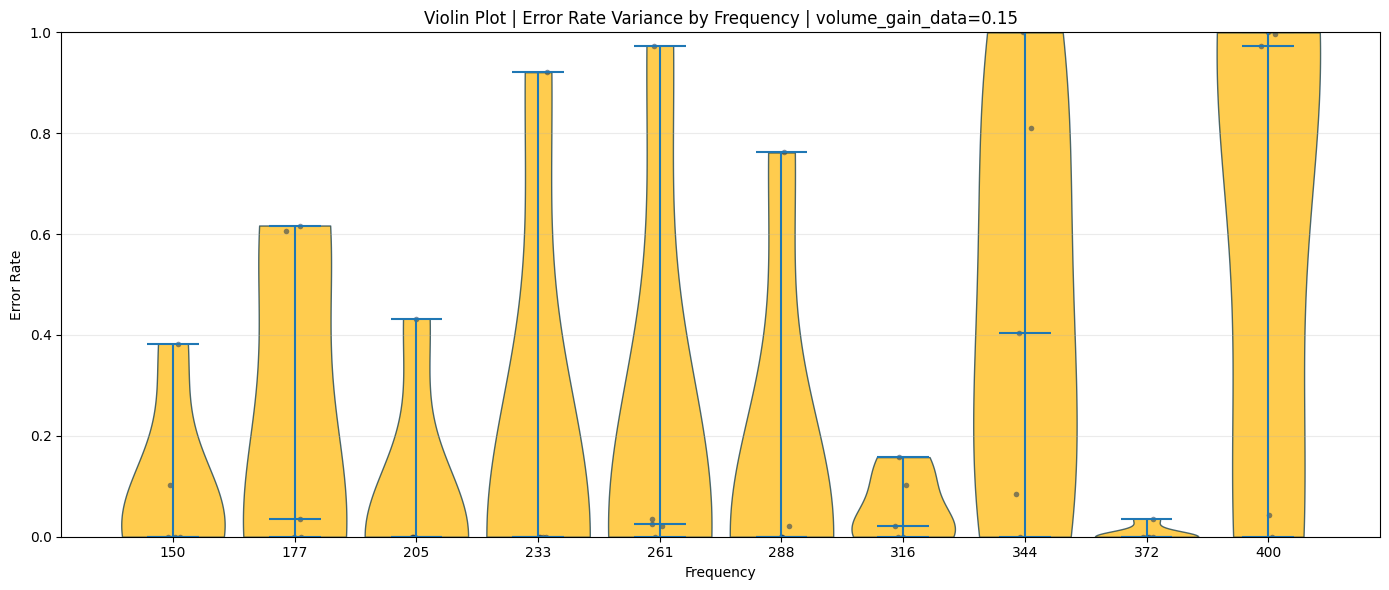

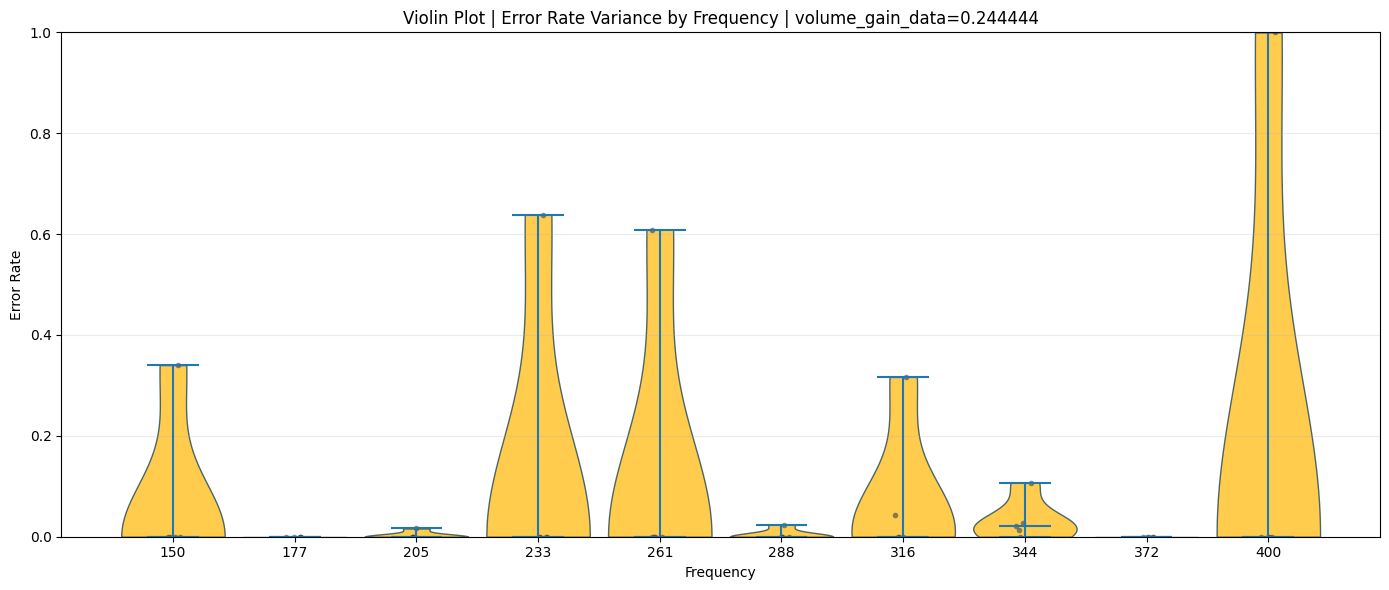

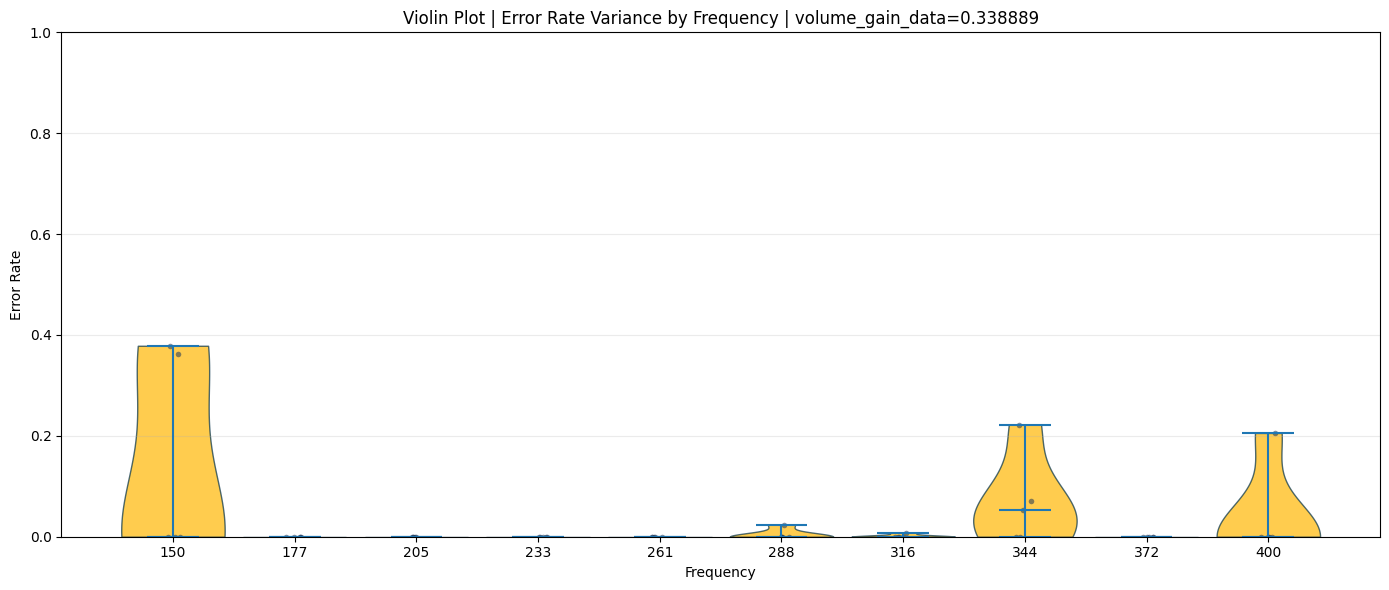

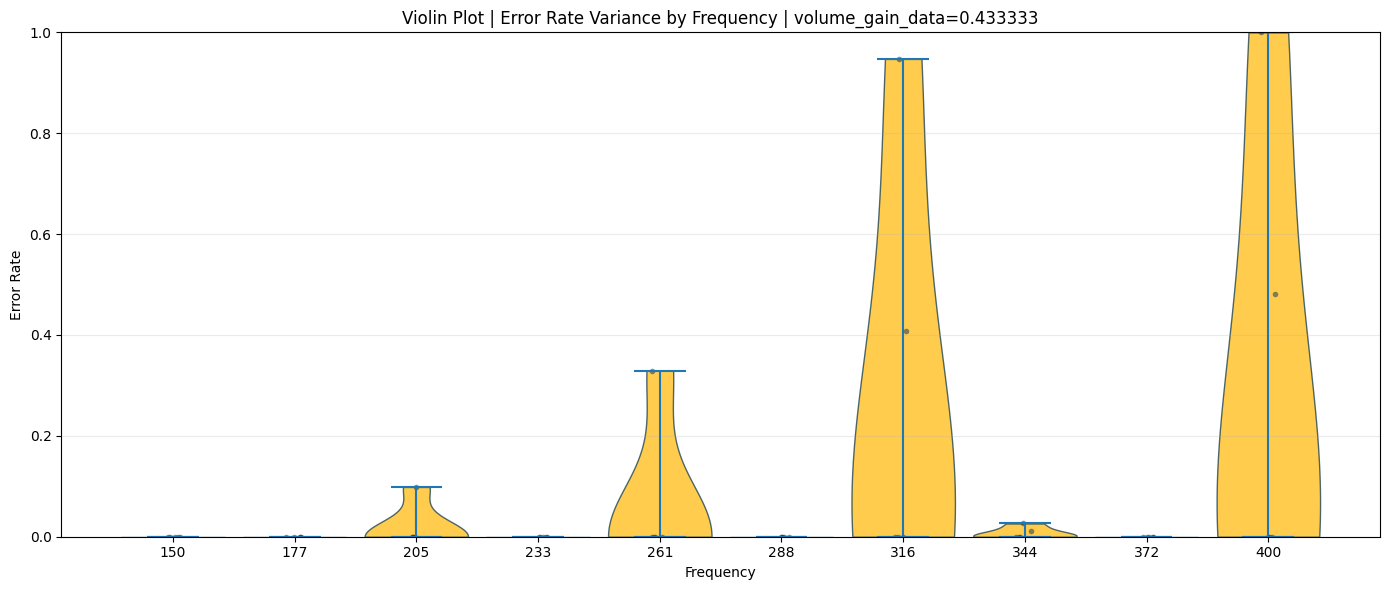

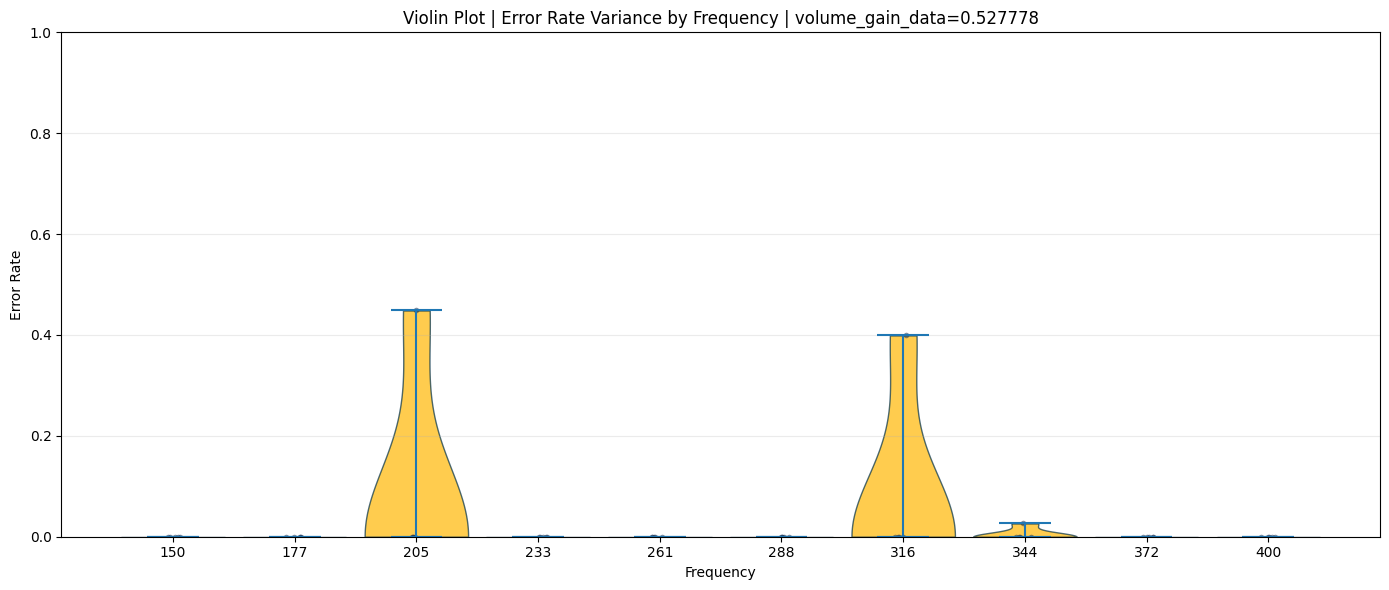

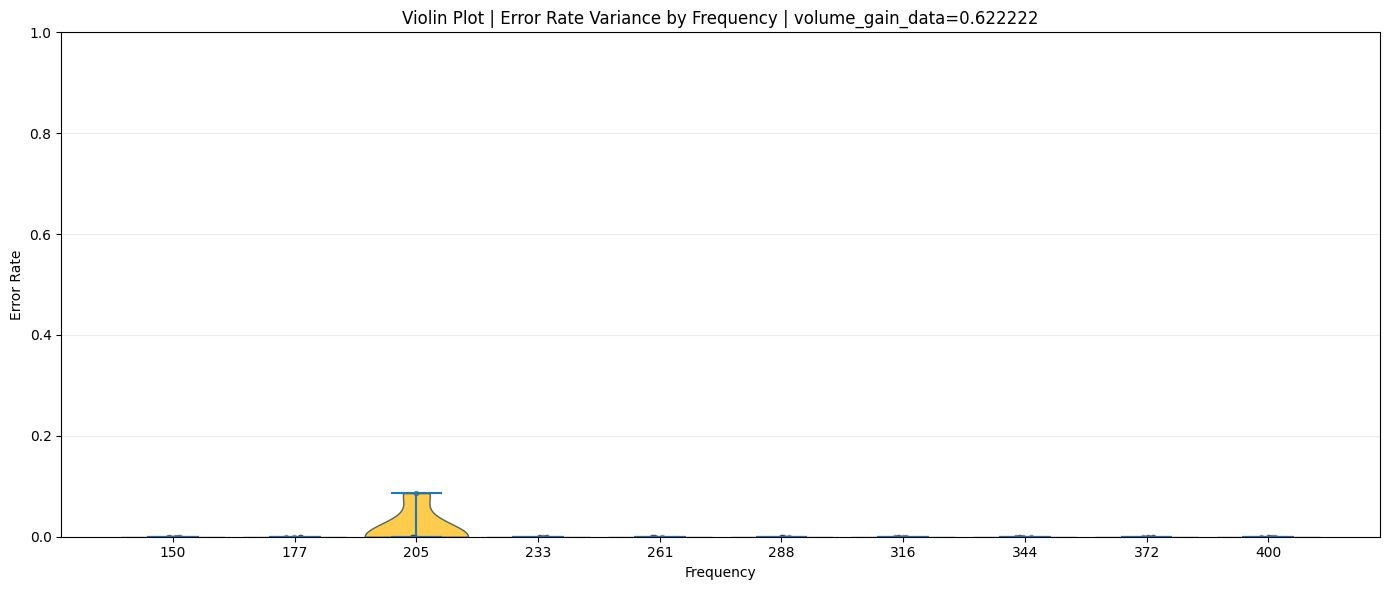

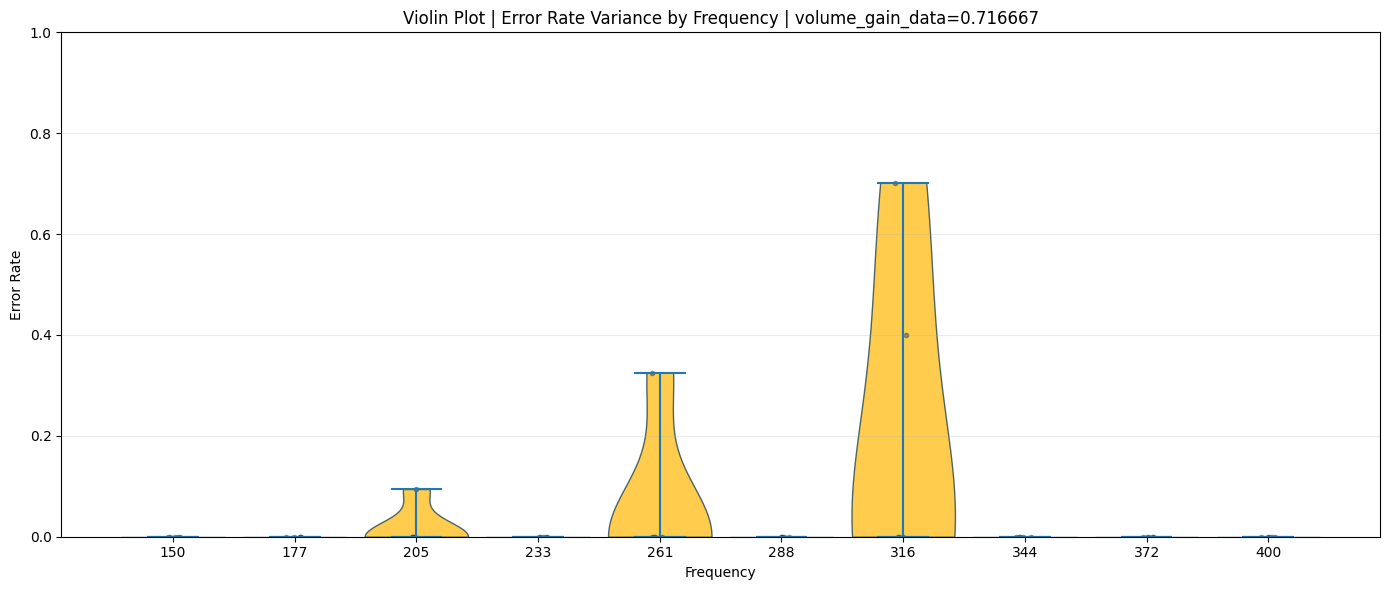

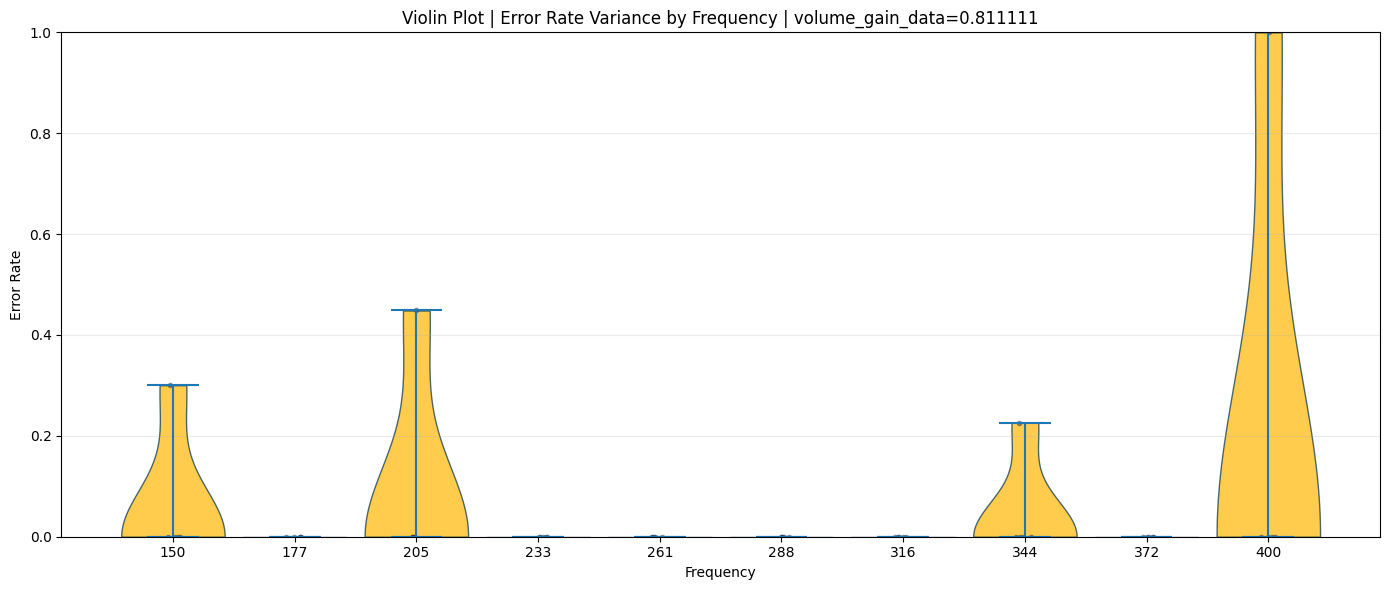

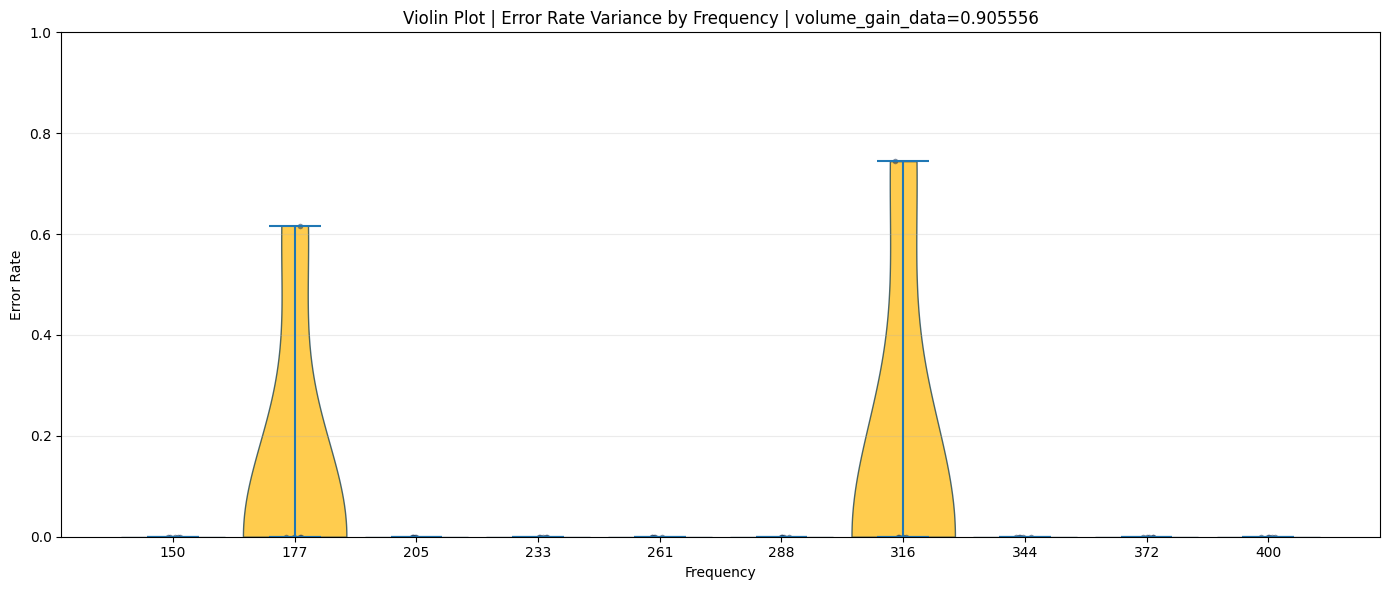

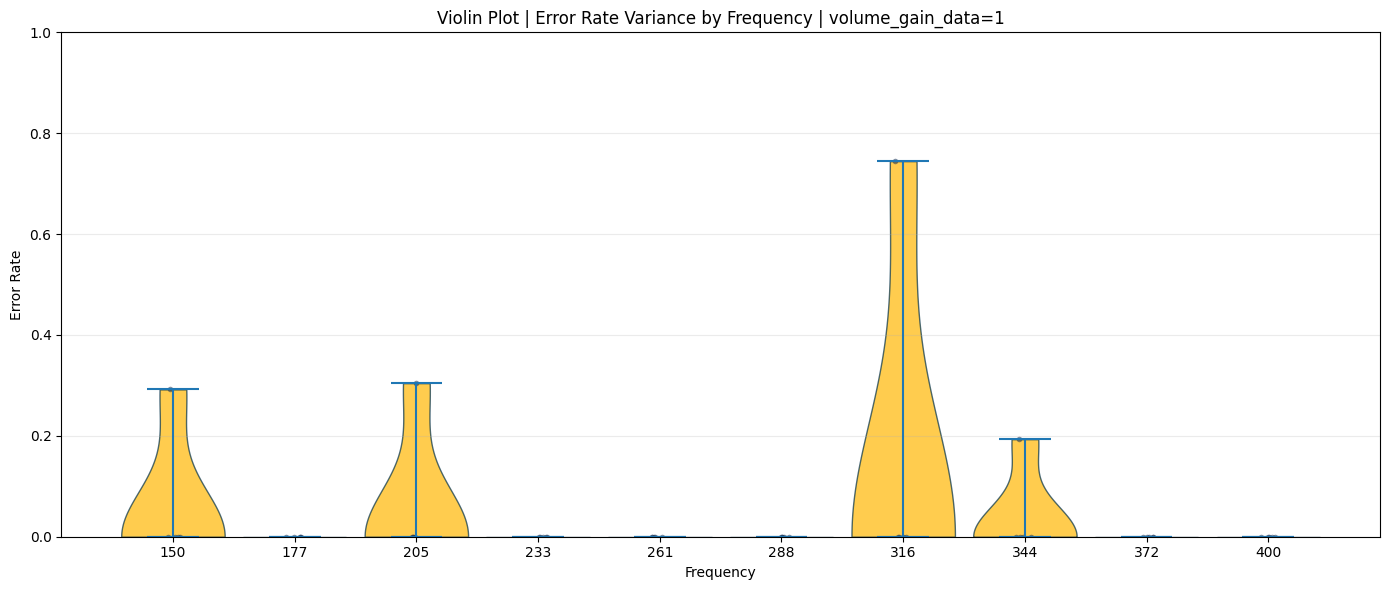

In [18]:
plot_error_rate_variance_for_all_volume_gains(
    df,
    prefer_box_if_sparse=True,
    min_points_per_group=3,
)

## 3D Interaction: Frequency, Data Volume, and Message
This plot shows interaction between `frequency`, `volume_gain_data`, and message index.
Color and marker size encode `error_rate` (lower is better).

In [19]:
import plotly.express as px

plot_df = prepare_plot_df(df).copy()
plot_df["error_rate_clipped"] = plot_df["error_rate"].clip(0, 1)
plot_df["marker_size"] = 6 + plot_df["error_rate_clipped"] * 18

message_order = plot_df["message_label"].drop_duplicates().tolist()
message_to_idx = {message: idx for idx, message in enumerate(message_order)}
plot_df["message_idx"] = plot_df["message_label"].map(message_to_idx)
plot_df["message_short"] = plot_df["message_label"].map(lambda m: shorten_message(m, 40))

fig = px.scatter_3d(
    plot_df,
    x="frequency",
    y="volume_gain_data",
    z="message_idx",
    color="error_rate",
    size="marker_size",
    symbol="message_short",
    size_max=24,
    color_continuous_scale="Viridis",
    opacity=0.85,
    title="3D Interaction: Frequency vs Data Volume vs Message",
    labels={
        "frequency": "Frequency",
        "volume_gain_data": "Volume Gain Data",
        "message_idx": "Message",
        "error_rate": "Error Rate",
    },
)

fig.update_traces(
    marker={
        "line": {"width": 0.5, "color": "black"},
    }
)

fig.update_layout(
    scene={
        "camera": {"eye": {"x": 1.5, "y": 1.5, "z": 0.9}},
        "zaxis": {
            "tickvals": list(range(len(message_order))),
            "ticktext": [shorten_message(message, 30) for message in message_order],
        },
    },
    margin={"l": 0, "r": 0, "t": 40, "b": 0},
    height=850,
)

fig.show()